# Simple Linear Regression (Single Feature)
#### The Task: Find a simple dataset with one continuous feature and one target (e.g., predicting a student's test score based on hours studied).
### Objectives: 
#### Split the data into training and testing sets.
#### Use sklearn.linear_model.LinearRegression to train the model.
#### Create a scatter plot of the test data and overlay the predicted line of best fit.

--- Task 1: Simple Linear Regression ---


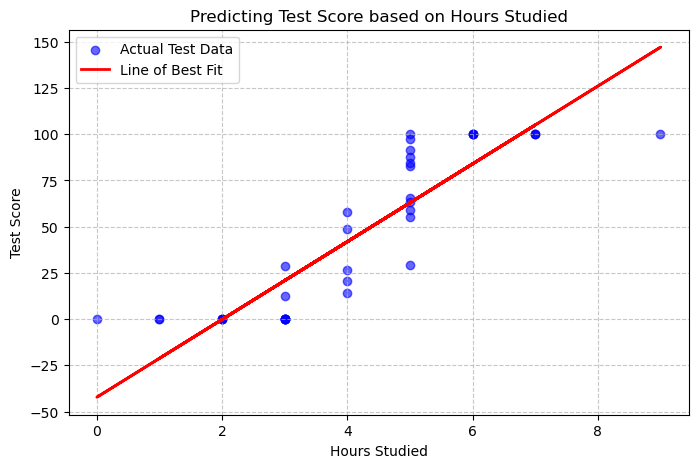

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

print("--- Task 1: Simple Linear Regression ---")

df_study = pd.read_csv('study_hour.csv')

X_simple = df_study[['Hours_Studied']]
y_simple = df_study['Test_Score']

# Split the data (80% train, 20% test)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)
# Train the Simple Linear Regression model
simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

# Predict test scores using the testing set
y_pred_s = simple_model.predict(X_test_s)

# Create a scatter plot of the test data and overlay the predicted line of best fit
plt.figure(figsize=(8, 5))
plt.scatter(X_test_s, y_test_s, color='blue', alpha=0.6, label='Actual Test Data')
plt.plot(X_test_s, y_pred_s, color='red', linewidth=2, label='Line of Best Fit')

plt.title('Predicting Test Score based on Hours Studied')
plt.xlabel('Hours Studied')
plt.ylabel('Test Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Multiple Linear Regression & Feature Interpretation
#### Dataset: from sklearn.datasets import fetch_california_housing
#### The Task: Use a multi-featured dataset like the California Housing Dataset.
## Objectives:
#### Perform basic Exploratory Data Analysis (EDA) to check for correlations between features.
#### Train a Multiple Linear Regression model.
#### Extract and interpret the model's coefficients. Which features have the strongest positive or negative impact on the target variable?


--- Task 2: Multiple Linear Regression ---

Correlations with Target Variable (MedHouseVal):
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


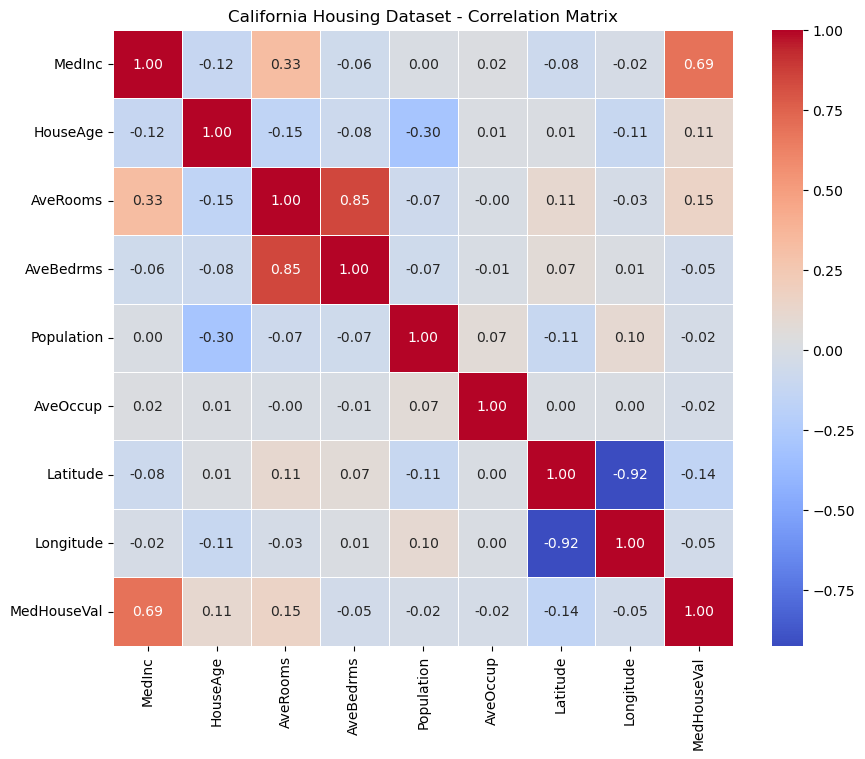


Model Coefficients (Impact on Median House Value):
      Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing

print("\n--- Task 2: Multiple Linear Regression ---")

california = fetch_california_housing(as_frame=True)
df_cali = california.frame

# Basic Exploratory Data Analysis (EDA)
correlation_matrix = df_cali.corr()
print("\nCorrelations with Target Variable (MedHouseVal):")
print(correlation_matrix['MedHouseVal'].sort_values(ascending=False))

# Plotting a heatmap to visualize correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("California Housing Dataset - Correlation Matrix")
plt.show()

# Define features (X) and target (y)
X_multi = california.data
y_multi = california.target

# Split the data into training and testing sets
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

# Train the Multiple Linear Regression model
multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

# Extract and interpret the model's coefficients
coefficients = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': multi_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nModel Coefficients (Impact on Median House Value):")
print(coefficients)